IMPORT LIBRARY

In [45]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *

import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import os

In [46]:
BASE_DIR = Path.cwd()

while BASE_DIR.name != "Final_Project":

    BASE_DIR = BASE_DIR.parent


os.chdir(BASE_DIR)

print(os.getcwd())

FINAL_DIR = BASE_DIR / "data" / "final"
FINAL_DIR.mkdir(parents=True,exist_ok=True)

c:\Users\sever\Documents\Project_Coolyeah\Lab_MCI\Final_Project


In [47]:
spark = SparkSession.builder \
    .master("local[*]") \
    .appName("MasterCustomerExperience") \
    .getOrCreate()

DATA LOADING

In [48]:
cleaned_orders_df = spark.read.parquet(
    "data/cleaned/orders_cleaned"
)

cleaned_reviews_df = spark.read.parquet(
    "data/cleaned/reviews_cleaned"
)

cleaned_products_df = spark.read.parquet(
    "data/cleaned/products_cleaned"
)

cleaned_items_df = spark.read.parquet(
    "data/cleaned/items_cleaned"
)

cleaned_customers_df = spark.read.parquet(
    "data/cleaned/customers_cleaned"
)

cleaned_sellers_df = spark.read.parquet(
    "data/cleaned/sellers_cleaned"
)

cleaned_translation_df = spark.read.parquet(
    "data/cleaned/translations_cleaned"
)

JOIN TABLE

In [49]:
# =====================================================
# JOIN REVIEWS + ORDERS
# =====================================================

master_df = cleaned_reviews_df.join(
    cleaned_orders_df,
    on="order_id",
    how="inner"
)


# =====================================================
# JOIN ORDER ITEMS
# =====================================================

master_df = master_df.join(
    cleaned_items_df,
    on="order_id",
    how="inner"
)


# =====================================================
# JOIN PRODUCTS
# =====================================================

master_df = master_df.join(
    cleaned_products_df,
    on="product_id",
    how="left"
)


# =====================================================
# JOIN CATEGORY TRANSLATION
# =====================================================

master_df = master_df.join(
    cleaned_translation_df,
    on="product_category_name",
    how="left"
)

# =====================================================
# JOIN CUSTOMERS
# =====================================================

master_df = master_df.join(
    cleaned_customers_df,
    on="customer_id",
    how="left"
)

# =====================================================
# JOIN SELLERS
# =====================================================

master_df = master_df.join(
    cleaned_sellers_df,
    on="seller_id",
    how="left"
)


DATA SELECTION

In [50]:
master_df = master_df.select(

    # REVIEW

    "order_id",
    "review_score",
    "review_comment_message",
    "sentiment",

    # PRODUCT

    "product_category_name_english",

    # ORDER

    "delivery_delay_days",
    "delivery_status",

    # CUSTOMER
    "customer_state",

    # SELLER

    "seller_id",
    "seller_state"
)

In [51]:
print("\n===== MASTER DATASET SAMPLE =====")

master_df.show(10,truncate=False)


===== MASTER DATASET SAMPLE =====
+--------------------------------+------------+----------------------------------------------------------------------------------------------------+---------+-----------------------------+-------------------+---------------+--------------+--------------------------------+------------+
|order_id                        |review_score|review_comment_message                                                                              |sentiment|product_category_name_english|delivery_delay_days|delivery_status|customer_state|seller_id                       |seller_state|
+--------------------------------+------------+----------------------------------------------------------------------------------------------------+---------+-----------------------------+-------------------+---------------+--------------+--------------------------------+------------+
|c72add79a1bef8c55628b377b01eb02d|4           |NULL                                                        

In [52]:
print("\n===== MASTER DATASET SCHEMA =====")

master_df.printSchema()


===== MASTER DATASET SCHEMA =====
root
 |-- order_id: string (nullable = true)
 |-- review_score: integer (nullable = true)
 |-- review_comment_message: string (nullable = true)
 |-- sentiment: string (nullable = true)
 |-- product_category_name_english: string (nullable = true)
 |-- delivery_delay_days: integer (nullable = true)
 |-- delivery_status: string (nullable = true)
 |-- customer_state: string (nullable = true)
 |-- seller_id: string (nullable = true)
 |-- seller_state: string (nullable = true)



In [53]:
print("\n===== TOTAL ROWS =====")

print(
    master_df.count()
)


===== TOTAL ROWS =====
109125


In [54]:
print("\n===== MISSING VALUES =====")

missing_df = master_df.select([

    count(
        when(
            col(c).isNull(),
            c
        )
    ).alias(c)

    for c in master_df.columns

])

missing_df.show()


===== MISSING VALUES =====
+--------+------------+----------------------+---------+-----------------------------+-------------------+---------------+--------------+---------+------------+
|order_id|review_score|review_comment_message|sentiment|product_category_name_english|delivery_delay_days|delivery_status|customer_state|seller_id|seller_state|
+--------+------------+----------------------+---------+-----------------------------+-------------------+---------------+--------------+---------+------------+
|       0|           0|                 63334|        0|                         1548|                  0|              0|             0|        0|           0|
+--------+------------+----------------------+---------+-----------------------------+-------------------+---------------+--------------+---------+------------+



In [55]:
null_category_df = master_df.filter(
    col("product_category_name_english").isNull()
)

print("\n===== NULL CATEGORY SAMPLE =====")

null_category_df.show(
    20,
    truncate=False
)


===== NULL CATEGORY SAMPLE =====
+--------------------------------+------------+------------------------------------------------------------------------------+---------+-----------------------------+-------------------+---------------+--------------+--------------------------------+------------+
|order_id                        |review_score|review_comment_message                                                        |sentiment|product_category_name_english|delivery_delay_days|delivery_status|customer_state|seller_id                       |seller_state|
+--------------------------------+------------+------------------------------------------------------------------------------+---------+-----------------------------+-------------------+---------------+--------------+--------------------------------+------------+
|686c88e6a063eab771785d988188f5c1|5           |NULL                                                                          |positive |NULL                         |-2      

DATA CLEANING

In [56]:
cleaned_master_df = master_df.filter(
    col("product_category_name_english").isNotNull()
)
cleaned_master_df = cleaned_master_df.filter(
    col("delivery_status").isNotNull()
)
cleaned_master_df = cleaned_master_df.fillna({
    "review_comment_message": "no_review"
})
cleaned_master_df = cleaned_master_df.dropDuplicates()


In [57]:
print("\n===== CLEANED MASTER DATASET =====")

cleaned_master_df.show(
    10,
    truncate=False
)

print("\n===== TOTAL CLEANED ROWS =====")

print(
    cleaned_master_df.count()
)


===== CLEANED MASTER DATASET =====
+--------------------------------+------------+-----------------------------------------------------------+---------+-----------------------------+-------------------+---------------+--------------+--------------------------------+------------+
|order_id                        |review_score|review_comment_message                                     |sentiment|product_category_name_english|delivery_delay_days|delivery_status|customer_state|seller_id                       |seller_state|
+--------------------------------+------------+-----------------------------------------------------------+---------+-----------------------------+-------------------+---------------+--------------+--------------------------------+------------+
|10c3c7fea20a1ed15c6e55e90b3fb084|1           |Não recebi o produto e nem meu dinheiro de volta           |negative |perfumery                    |17                 |late           |SP            |3c7c4a49ec3c6550809089c6a2ca937

DATA COMPARISON AND DISTRIBUTION

In [58]:
# =====================================================
# SAME STATE SHIPPING FEATURE
# =====================================================

print("\n===== SAME STATE SHIPPING FEATURE =====")

cleaned_master_df = cleaned_master_df.withColumn(
    "same_state_shipping",
    when(
        col("customer_state") == col("seller_state"), 1
    ).otherwise(0)
)

cleaned_master_df.limit(5).toPandas()


===== SAME STATE SHIPPING FEATURE =====


,order_id,review_score,review_comment_message,sentiment,product_category_name_english,delivery_delay_days,delivery_status,customer_state,seller_id,seller_state,same_state_shipping
0,10c3c7fea20a1ed15c6e55e90b3fb084,1,Não recebi o produto e nem meu dinheiro de volta,negative,perfumery,17,late,SP,3c7c4a49ec3c6550809089c6a2ca9370,SP,1
1,a3e4fb1d4c4c04deb731bae74f190339,5,Produto de ótima qualidade e chegou antes do p...,positive,sports_leisure,-21,early,AP,376a891762bbdecbc02b4b6adec3fdda,GO,0
2,d7e87a1388d89fa6d7841f32c6954c2e,1,Foram pedidos 2 unidades e recebemos só 1,negative,health_beauty,-25,early,SP,8444e55c1f13cd5c179851e5ca5ebd00,MG,0
3,741bffa3ccd9486d8050c172ea085d43,5,no_review,positive,watches_gifts,-34,early,PR,d921b68bf747894be13a97ae52b0f386,MG,0
4,c6eb7d8978a0d7a7e592ef611e4daf04,5,no_review,positive,fashion_underwear_beach,-19,early,MG,a6fe7de3d16f6149ffe280349a8535a0,SP,0


,same_state_shipping,sentiment,count
0,1,negative,3721
1,0,neutral,5313
2,1,neutral,2664
3,1,positive,28008
4,0,positive,46979
5,0,negative,8916


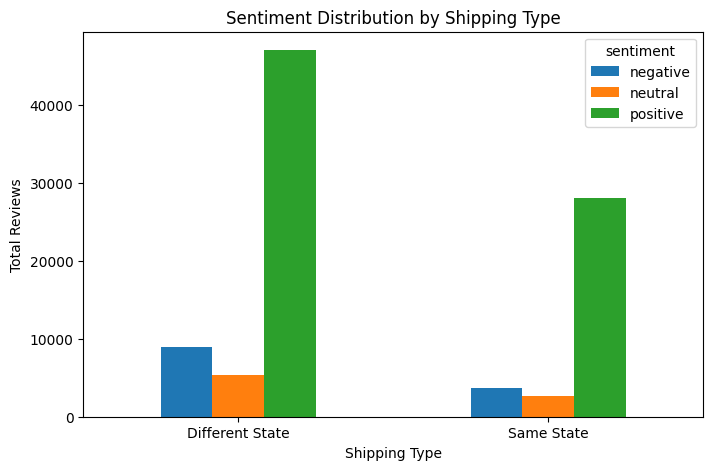

In [59]:
# =====================================================
# SENTIMENT VS SAME STATE SHIPPING
# =====================================================

sentiment_same_state_pd = (
    cleaned_master_df
    .groupBy(
        "same_state_shipping",
        "sentiment"
    )
    .count()
    .toPandas()
)


display(sentiment_same_state_pd.head(10))


sentiment_pivot = (
    sentiment_same_state_pd
    .pivot(
        index="same_state_shipping",
        columns="sentiment",
        values="count"
    )
    .fillna(0)
)


sentiment_pivot.index = [
    "Different State",
    "Same State"
]


sentiment_pivot.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title(
    "Sentiment Distribution by Shipping Type"
)

plt.xlabel(
    "Shipping Type"
)

plt.ylabel(
    "Total Reviews"
)

plt.xticks(rotation=0)

plt.show()

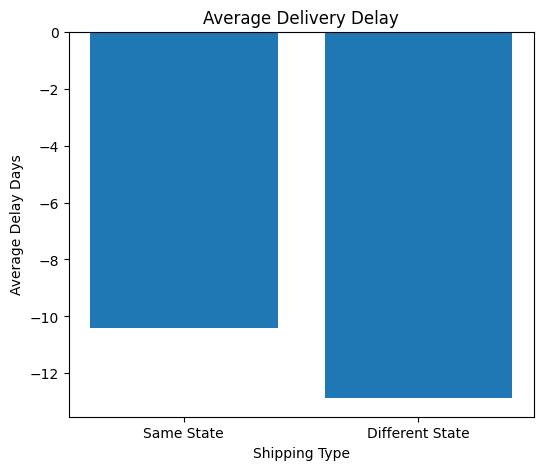

In [60]:
# =====================================================
# DELIVERY DELAY VS SAME STATE SHIPPING
# =====================================================

delay_same_state_pd = (
    cleaned_master_df
    .groupBy("same_state_shipping")
    .agg(
        avg("delivery_delay_days")
        .alias("avg_delay")
    ).toPandas()
)

delay_same_state_pd["shipping_type"] = (
    delay_same_state_pd[
        "same_state_shipping"
    ].map({
        0: "Different State",
        1: "Same State"
    })
)

plt.figure(figsize=(6,5))
plt.bar(
    delay_same_state_pd["shipping_type"],
    delay_same_state_pd["avg_delay"]
)

plt.title(
    "Average Delivery Delay"
)

plt.xlabel(
    "Shipping Type"
)

plt.ylabel(
    "Average Delay Days"
)

plt.show()

In [61]:
# =====================================================
# DELIVERY STATUS VS REVIEW SCORE
# =====================================================

print("\n===== DELIVERY STATUS VS REVIEW SCORE =====")

delivery_review = (
    cleaned_master_df.groupBy("delivery_status")
    .agg(
        avg("review_score")
        .alias("avg_review_score")
    )
)

delivery_review_pd = (
    delivery_review.toPandas()
)

display(delivery_review_pd)


===== DELIVERY STATUS VS REVIEW SCORE =====


,delivery_status,avg_review_score
0,late,2.272843
1,on_time,4.040637
2,early,4.274789


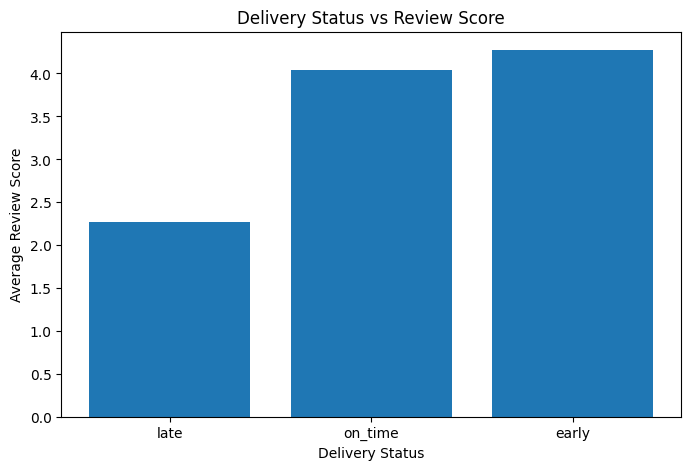

In [62]:
plt.figure(figsize=(8,5))

plt.bar(
    delivery_review_pd["delivery_status"],
    delivery_review_pd["avg_review_score"]
)

plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score")
plt.title("Delivery Status vs Review Score")

plt.show()

In [63]:
print("\n===== SENTIMENT VS DELIVERY STATUS =====")

sentiment_delivery = (
    cleaned_master_df.groupBy(
        "delivery_status",
        "sentiment"
    )
    .count()
)

sentiment_delivery_pd = (
    sentiment_delivery.toPandas()
)

display(sentiment_delivery_pd)



===== SENTIMENT VS DELIVERY STATUS =====


,delivery_status,sentiment,count
0,early,negative,8566
1,on_time,neutral,172
2,late,positive,1683
3,on_time,positive,928
4,late,neutral,683
5,early,neutral,7122
6,on_time,negative,155
7,early,positive,72376
8,late,negative,3916



===== SENTIMENT VS DELIVERY STATUS VISUALIZATION =====


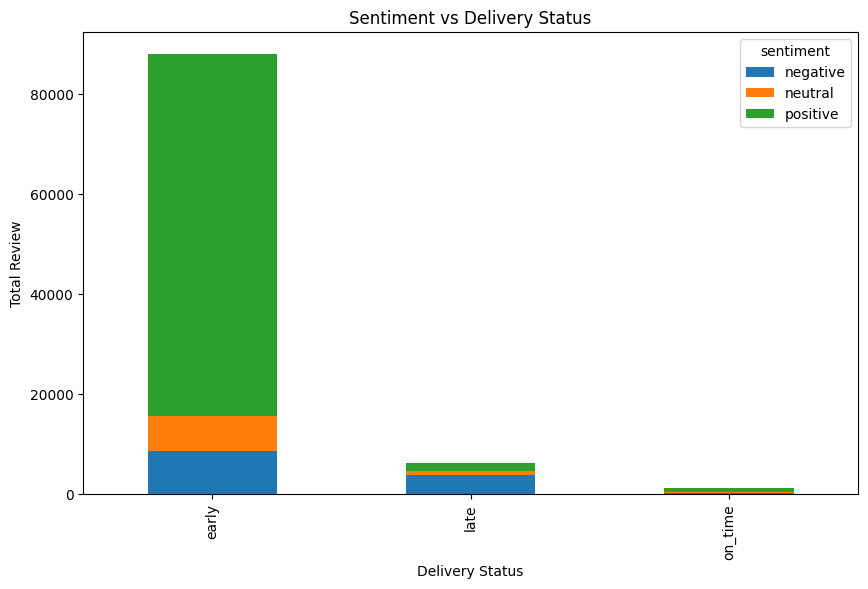

In [64]:
print("\n===== SENTIMENT VS DELIVERY STATUS VISUALIZATION =====")

sentiment_delivery = (
    cleaned_master_df.groupBy(
        "delivery_status",
        "sentiment"
    )
    .count()
)

sentiment_delivery_pd = (
    sentiment_delivery.toPandas()
)

pivot_df = sentiment_delivery_pd.pivot(
    index="delivery_status",
    columns="sentiment",
    values="count"
).fillna(0)

pivot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.xlabel("Delivery Status")
plt.ylabel("Total Review")
plt.title("Sentiment vs Delivery Status")

plt.show()

In [65]:
print("\n===== CATEGORY VS REVIEW SCORE =====")

category_review = (
    cleaned_master_df.groupBy(
        "product_category_name_english"
    )
    .agg(
        avg("review_score")
        .alias("avg_review_score"),

        count("*")
        .alias("total_review")
    )
    .orderBy("avg_review_score")
)

category_review_pd = (
    category_review.toPandas()
)

display(
    category_review_pd.head(10),
    category_review_pd.tail(10)
)



===== CATEGORY VS REVIEW SCORE =====


,product_category_name_english,avg_review_score,total_review
0,security_and_services,2.500000,2
1,office_furniture,3.641129,1240
2,fashion_male_clothing,3.790476,105
3,home_comfort_2,3.826087,23
4,audio,3.840580,345
5,home_confort,3.894872,390
6,furniture_mattress_and_upholstery,3.911765,34
7,fashio_female_clothing,3.916667,36
8,diapers_and_hygiene,3.960000,25
9,fixed_telephony,3.966507,209


,product_category_name_english,avg_review_score,total_review
61,fashion_sport,4.384615,26
62,flowers,4.392857,28
63,books_technical,4.425197,254
64,costruction_tools_tools,4.425532,94
65,small_appliances_home_oven_and_coffee,4.430556,72
66,books_imported,4.440000,50
67,food_drink,4.444954,218
68,books_general_interest,4.533605,491
69,cds_dvds_musicals,4.666667,12
70,fashion_childrens_clothes,5.000000,7


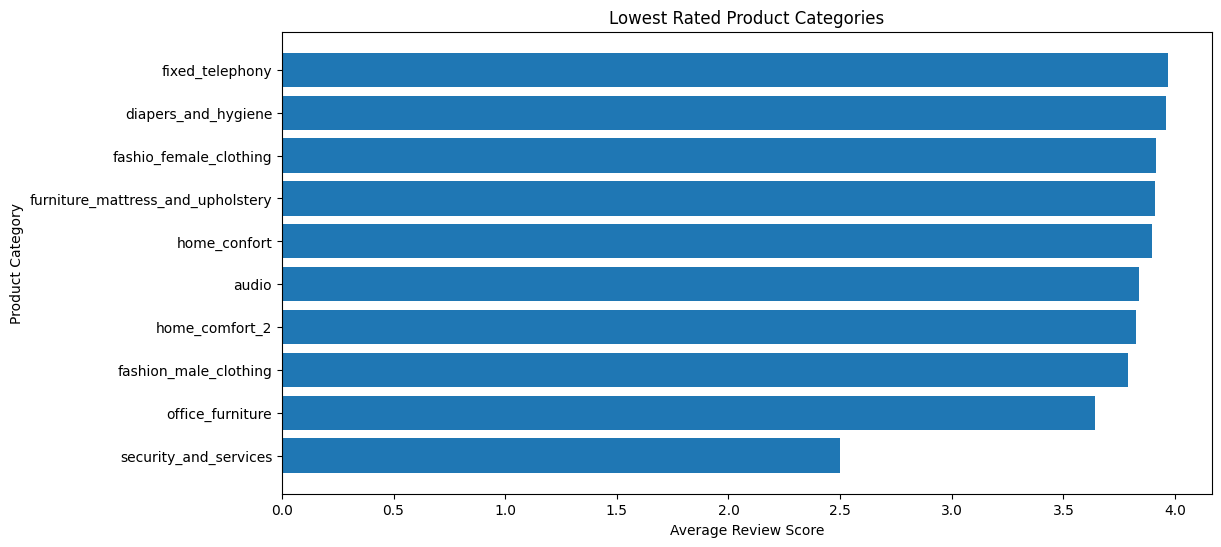

In [66]:
plt.figure(figsize=(12,6))

plt.barh(
    category_review_pd[
        "product_category_name_english"
    ].head(10),

    category_review_pd[
        "avg_review_score"
    ].head(10)
)

plt.xlabel("Average Review Score")
plt.ylabel("Product Category")
plt.title("Lowest Rated Product Categories")

plt.show()

In [67]:
print("\n===== MOST NEGATIVE CATEGORY =====")

negative_category = (
    cleaned_master_df.filter(
        col("review_score") <= 2
    )
    .groupBy(
        "product_category_name_english"
    )
    .count()
    .orderBy(desc("count"))
)

negative_pd = (
    negative_category.toPandas()
)

display(
    negative_pd.head(10)
)


===== MOST NEGATIVE CATEGORY =====


,product_category_name_english,count
0,bed_bath_table,1561
1,furniture_decor,990
2,health_beauty,988
3,computers_accessories,971
4,sports_leisure,877
5,watches_gifts,769
6,housewares,683
7,telephony,584
8,auto,499
9,toys,437


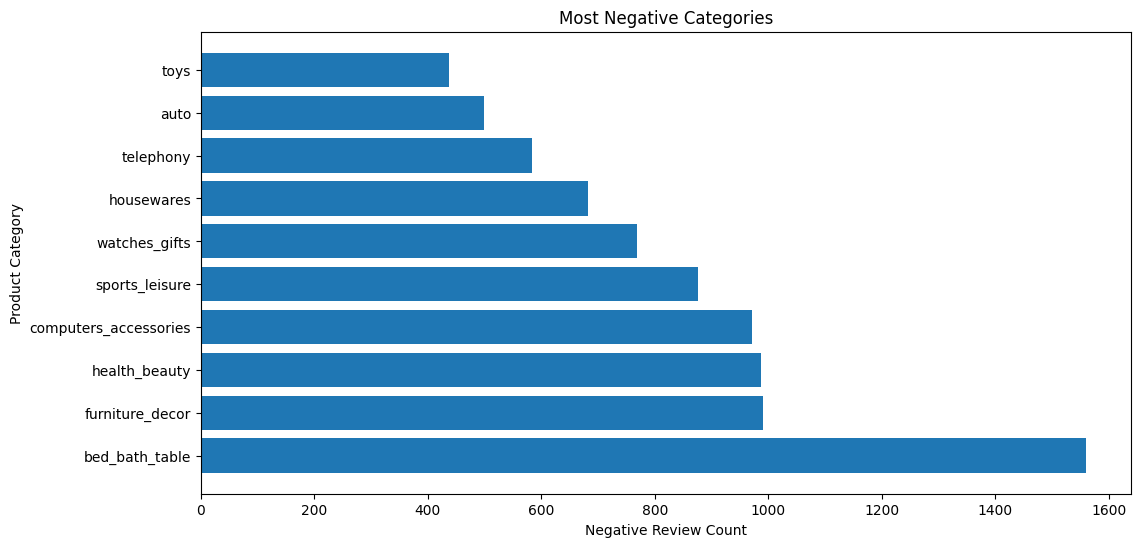

In [68]:
plt.figure(figsize=(12,6))

plt.barh(
    negative_pd[
        "product_category_name_english"
    ].head(10),

    negative_pd[
        "count"
    ].head(10)
)

plt.xlabel("Negative Review Count")
plt.ylabel("Product Category")
plt.title("Most Negative Categories")

plt.show()

In [69]:
print("\n===== DELIVERY DELAY VS REVIEW SCORE =====")

delay_review = (
    cleaned_master_df.groupBy(
        "delivery_delay_days"
    )
    .agg(
        avg("review_score")
        .alias("avg_review_score")
    )
    .orderBy("delivery_delay_days")
)

delay_review_pd = (
    delay_review.toPandas()
)

display(
    delay_review_pd.head(10),
    delay_review_pd.tail(10)
)


===== DELIVERY DELAY VS REVIEW SCORE =====


,delivery_delay_days,avg_review_score
0,-147,5.0
1,-140,5.0
2,-135,3.0
3,-124,5.0
4,-109,5.0
5,-84,5.0
6,-83,5.0
7,-78,5.0
8,-77,5.0
9,-76,5.0


,delivery_delay_days,avg_review_score
184,153,4.0
185,155,4.5
186,159,3.0
187,161,4.0
188,162,3.0
189,165,1.0
190,166,1.0
191,167,1.0
192,175,1.0
193,188,2.0


In [70]:
cleaned_master_df.limit(5).toPandas()

,order_id,review_score,review_comment_message,sentiment,product_category_name_english,delivery_delay_days,delivery_status,customer_state,seller_id,seller_state,same_state_shipping
0,10c3c7fea20a1ed15c6e55e90b3fb084,1,Não recebi o produto e nem meu dinheiro de volta,negative,perfumery,17,late,SP,3c7c4a49ec3c6550809089c6a2ca9370,SP,1
1,a3e4fb1d4c4c04deb731bae74f190339,5,Produto de ótima qualidade e chegou antes do p...,positive,sports_leisure,-21,early,AP,376a891762bbdecbc02b4b6adec3fdda,GO,0
2,d7e87a1388d89fa6d7841f32c6954c2e,1,Foram pedidos 2 unidades e recebemos só 1,negative,health_beauty,-25,early,SP,8444e55c1f13cd5c179851e5ca5ebd00,MG,0
3,741bffa3ccd9486d8050c172ea085d43,5,no_review,positive,watches_gifts,-34,early,PR,d921b68bf747894be13a97ae52b0f386,MG,0
4,c6eb7d8978a0d7a7e592ef611e4daf04,5,no_review,positive,fashion_underwear_beach,-19,early,MG,a6fe7de3d16f6149ffe280349a8535a0,SP,0


In [71]:
seller_performance_df = (
    cleaned_master_df.groupBy("seller_id")
    .agg(
        avg("review_score").alias("seller_avg_review_score"),
        count("*").alias("seller_total_orders"),
        avg(
            when(col("delivery_delay_days") > 0, 1).otherwise(0)
        ).alias("seller_late_ratio")
    )
)

seller_performance_df.limit(20).toPandas()

,seller_id,seller_avg_review_score,seller_total_orders,seller_late_ratio
0,0ea22c1cfbdc755f86b9b54b39c16043,4.437500,224,0.008929
1,ec8879960bd2221d5c32f8e12f7da711,4.294118,34,0.176471
2,e63e8bfa530fb16910dd6956e592bb81,4.317073,41,0.048780
3,8e6cc767478edae941d9bd9eb778d77a,4.083333,96,0.052083
4,062ce95fa2ad4dfaedfc79260130565f,4.096154,52,0.038462
5,a49928bcdf77c55c6d6e05e09a9b4ca5,3.010526,95,0.221053
6,ff063b022a9a0aab91bad2c9088760b7,4.304348,92,0.032609
7,b3f19518fcec265b2e97af287725f981,4.428571,7,0.000000
8,c522be04e020c1e7b79f3acff36513d5,4.000000,6,0.333333
9,6eeed17989b0ae47c9f11ece6f38ea90,3.666667,3,0.000000


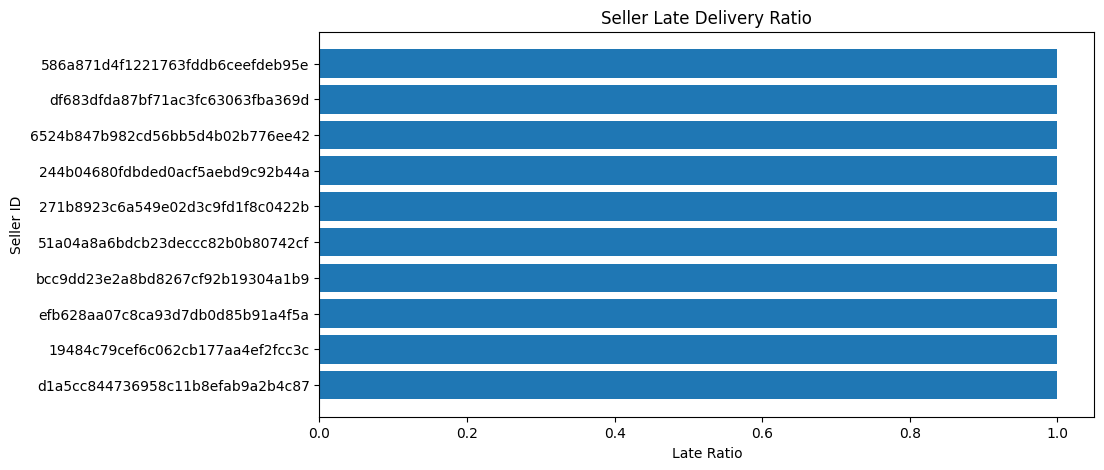

In [72]:
# =====================================================
# SELLER LATE RATIO DISTRIBUTION
# =====================================================

seller_late_pd = (
    cleaned_master_df
    .groupBy("seller_id")
    .agg(
        avg(
            when(
                col("delivery_delay_days") > 0,
                1
            ).otherwise(0)
        ).alias("late_ratio")
    )
    .orderBy(
        col("late_ratio").desc()
    )
    .limit(10)
    .toPandas()
)


plt.figure(figsize=(10,5))
plt.barh(
    seller_late_pd["seller_id"],
    seller_late_pd["late_ratio"]
)

plt.title(
    "Seller Late Delivery Ratio"
)

plt.xlabel(
    "Late Ratio"
)

plt.ylabel(
    "Seller ID"
)

plt.show()

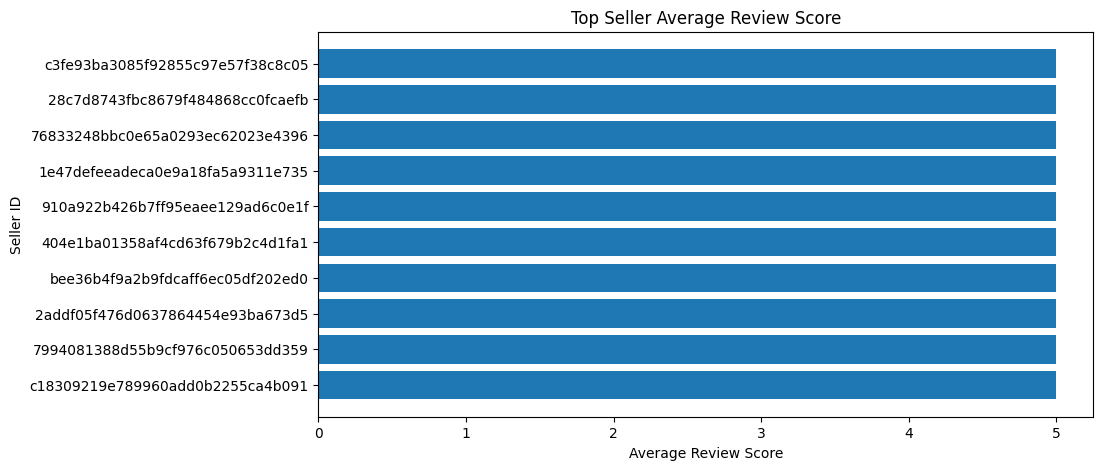

In [73]:
# =====================================================
# TOP SELLER AVERAGE REVIEW
# =====================================================

seller_review_pd = (

    cleaned_master_df

    .groupBy("seller_id")

    .agg(

        avg("review_score")
        .alias("avg_review_score")

    )

    .orderBy(
        col("avg_review_score").desc()
    )

    .limit(10)

    .toPandas()
)


plt.figure(figsize=(10,5))

plt.barh(

    seller_review_pd["seller_id"],

    seller_review_pd["avg_review_score"]
)

plt.title(
    "Top Seller Average Review Score"
)

plt.xlabel(
    "Average Review Score"
)

plt.ylabel(
    "Seller ID"
)

plt.show()

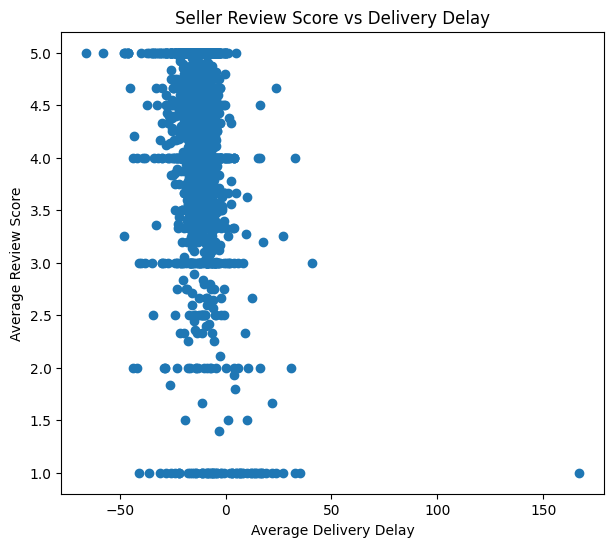

In [74]:
# =====================================================
# SELLER REVIEW SCORE VS DELIVERY DELAY
# =====================================================

seller_analysis_pd = (

    cleaned_master_df

    .groupBy("seller_id")

    .agg(

        avg("review_score")
        .alias("avg_review"),

        avg("delivery_delay_days")
        .alias("avg_delay")

    )

    .toPandas()
)


plt.figure(figsize=(7,6))

plt.scatter(

    seller_analysis_pd["avg_delay"],

    seller_analysis_pd["avg_review"]
)

plt.title(
    "Seller Review Score vs Delivery Delay"
)

plt.xlabel(
    "Average Delivery Delay"
)

plt.ylabel(
    "Average Review Score"
)

plt.show()

In [76]:
print("\n===== MISSING VALUES =====")

missing_df = cleaned_master_df.select([

    count(
        when(
            col(c).isNull(),
            c
        )
    ).alias(c)

    for c in cleaned_master_df.columns

])

missing_df.show()


===== MISSING VALUES =====
+--------+------------+----------------------+---------+-----------------------------+-------------------+---------------+--------------+---------+------------+-------------------+
|order_id|review_score|review_comment_message|sentiment|product_category_name_english|delivery_delay_days|delivery_status|customer_state|seller_id|seller_state|same_state_shipping|
+--------+------------+----------------------+---------+-----------------------------+-------------------+---------------+--------------+---------+------------+-------------------+
|       0|           0|                     0|        0|                            0|                  0|              0|             0|        0|           0|                  0|
+--------+------------+----------------------+---------+-----------------------------+-------------------+---------------+--------------+---------+------------+-------------------+



In [ ]:
os.makedirs(
    "data/final",
    exist_ok=True
)

cleaned_master_df.coalesce(1).write.mode("overwrite").parquet(
    str(FINAL_DIR / "master_cleaned")
)

print("cleaned_master saved")

cleaned_master saved
